# Amazon Queries Answers and Data Visualization

## Import Libraries

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Excel Sheets

In [ ]:
file_path = r"C:\Users\91860\Downloads\Amazon_dataset.xlsx"
sheets = pd.read_excel(file_path, sheet_name=None)


sheets.keys()

dict_keys(['Employees', 'Warehouses', 'Customers', 'Products', 'Orders', 'Reviews', 'Shipments', 'Departments', 'Order_items', 'Sellers'])

## Prepare Tables for Revenue Analysis

In [15]:
orders = sheets["Orders"]
order_items = sheets["Order_items"]
products = sheets["Products"]

In [ ]:
orders.head()

In [ ]:
order_items.head()

In [ ]:
products.head()

## Which Category has the highest amount of sales?

## Identify Join Keys

In [19]:
set(orders.columns) & set(order_items.columns)

{'order_id'}

In [20]:
set(order_items.columns) & set(products.columns)

{'price', 'product_id'}

## Join Orders, Order Items, and Products

In [23]:
order_product_data = (
    orders
    .merge(order_items, how='inner', on='order_id')
    .merge(products, how='inner', on='product_id')
    )
order_product_data.head()

,order_id,customer_id,order_date,total_amount,status,shipping_address,delivery_date,order_item_id,product_id,quantity,price_x,product_name,category,price_y,stock_quantity,warehouse_id,seller_id
0,5001,1001,2024-01-15 10:30:00,142.97,Delivered,"123 Main St, Seattle, WA",2024-01-18,1,101,2,29.99,Wireless Mouse,Electronics,29.99,500,1,1
1,5001,1001,2024-01-15 10:30:00,142.97,Delivered,"123 Main St, Seattle, WA",2024-01-18,2,102,3,12.99,USB-C Cable,Electronics,12.99,1000,1,1
2,5001,1001,2024-01-15 10:30:00,142.97,Delivered,"123 Main St, Seattle, WA",2024-01-18,3,104,1,45.99,Laptop Stand,Electronics,45.99,300,1,3
3,5002,1002,2024-01-16 14:20:00,79.99,Delivered,"456 Oak Ave, Portland, OR",2024-01-19,4,103,1,79.99,Coffee Maker,Home & Kitchen,79.99,200,2,2
4,5003,1001,2024-01-20 09:15:00,59.99,Shipped,"123 Main St, Seattle, WA",2024-01-23,5,107,1,59.99,Bluetooth Speaker,Electronics,59.99,250,1,1


## Create Revenue Column

In [27]:
order_product_data['revenue'] = order_product_data['price_x'] * order_product_data['quantity']
order_product_data[['quantity', 'price_x', 'revenue']]

,quantity,price_x,revenue
0,2,29.99,59.98
1,3,12.99,38.97
2,1,45.99,45.99
3,1,79.99,79.99
4,1,59.99,59.99
5,1,79.99,79.99
6,1,24.99,24.99
7,1,34.99,34.99
8,2,59.99,119.98
9,1,45.99,45.99


## Summarize Revenue by Category

In [38]:
category_revenue = (
    order_product_data
    .groupby("category", as_index=False)["revenue"]
    .sum()
    .sort_values(by='revenue', ascending=False)
)

category_revenue

,category,revenue
1,Electronics,400.89
2,Home & Kitchen,194.97
3,Sports,74.97
0,Books,39.99


## Visualization 1: Revenue by Product Category

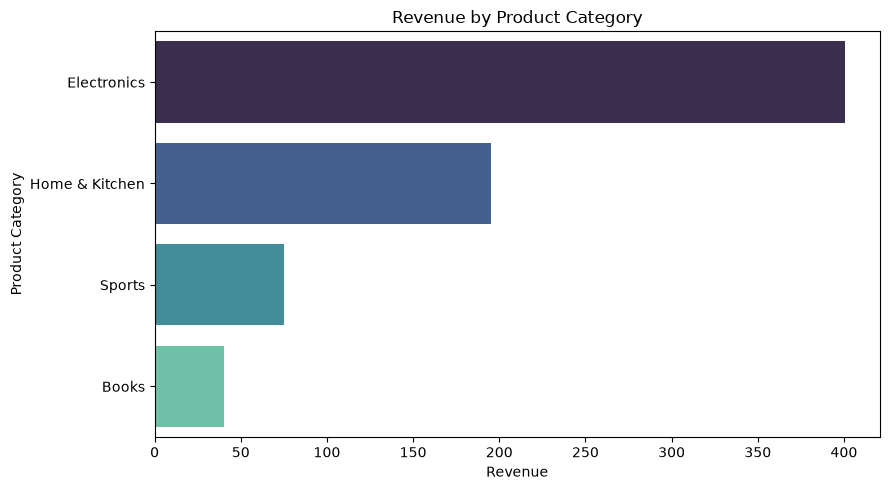

In [43]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=category_revenue,
    x="revenue",
    y="category",
    hue="category",
    palette="mako",
    legend=False
)

ax.set_title("Revenue by Product Category")
ax.set_xlabel("Revenue")
ax.set_ylabel("Product Category")

plt.tight_layout()
plt.show()

## Insight: Electronics generated the highest revenue, making it the strongest product category in this dataset.

## Which products generate the most revenue?

In [44]:
product_revenue = (
    order_product_data
    .groupby("product_name", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
)

product_revenue

,product_name,revenue
0,Bluetooth Speaker,179.97
1,Coffee Maker,159.98
3,Laptop Stand,91.98
6,Wireless Mouse,89.97
7,Yoga Mat,74.97
4,Python Programming Book,39.99
5,USB-C Cable,38.97
2,Desk Lamp,34.99


## Visualization 2: Top Products by Revenue

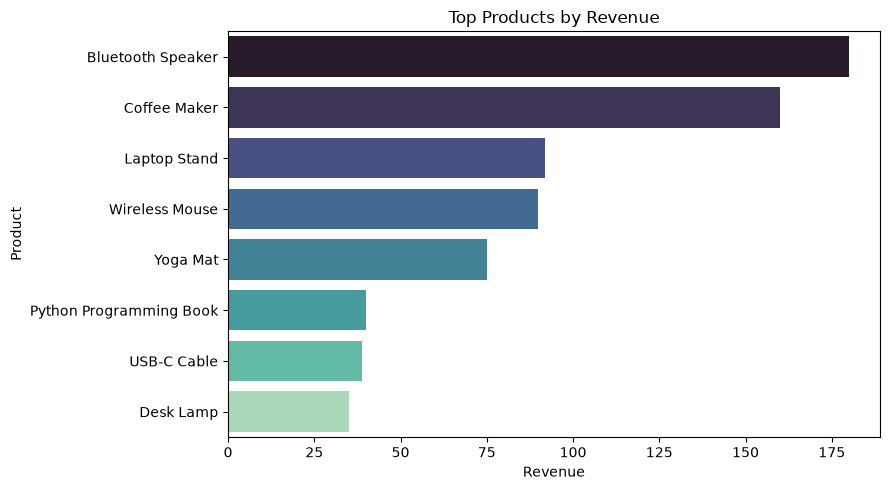

In [46]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=product_revenue,
    x="revenue",
    y="product_name",
    hue="product_name",
    palette="mako",
    legend=False
)

plt.title("Top Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## Insight: The top products by revenue show which individual items contributed the most to overall sales performance. In this case, we can very well see that it's bluetooth speakers from the category - electronics

## Which sellers generate the most revenue?

In [47]:
sellers = sheets["Sellers"]

seller_data = order_product_data.merge(
    sellers,
    on="seller_id",
    how="inner"
)

seller_revenue = (
    seller_data
    .groupby("seller_name", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
)

seller_revenue

,seller_name,revenue
3,TechGear Pro,308.91
2,HomeEssentials,269.94
1,GlobalElectronics,91.98
0,BookWorld,39.99


## Visualization 3: Revenue by Seller

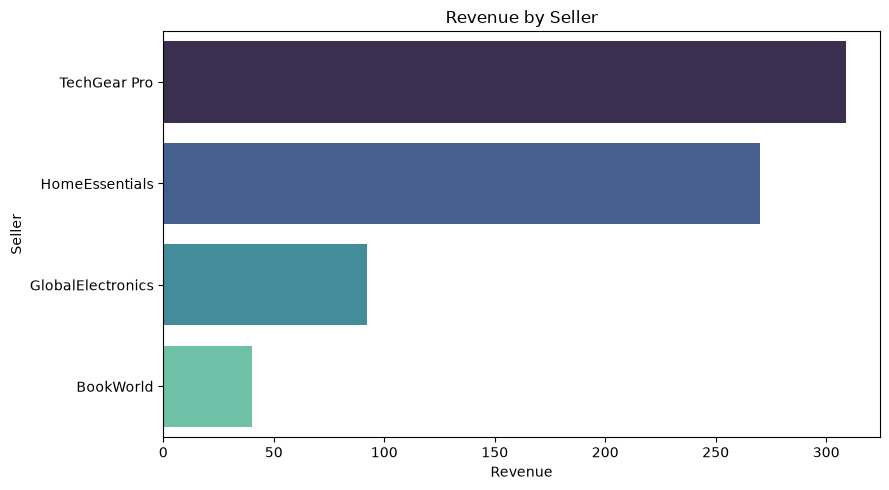

In [48]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=seller_revenue,
    x="revenue",
    y="seller_name",
    hue="seller_name",
    palette="mako",
    legend=False
)

plt.title("Revenue by Seller")
plt.xlabel("Revenue")
plt.ylabel("Seller")
plt.tight_layout()
plt.show()

## Insight: Seller revenue is concentrated among a few sellers, showing which marketplace partners drove the most sales.

## Do Prime customers generate more revenue?

In [49]:
customers = sheets["Customers"]

customer_data = order_product_data.merge(
    customers,
    on="customer_id",
    how="inner"
)

customer_data["prime_status"] = customer_data["prime_member"].map({
    1: "Prime",
    0: "Non-Prime"
}).fillna("Unknown")

prime_revenue = (
    customer_data
    .groupby("prime_status", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
)

prime_revenue

,prime_status,revenue
0,Prime,565.85
1,Unknown,144.97


## Visualization 4: Revenue by Prime Membership

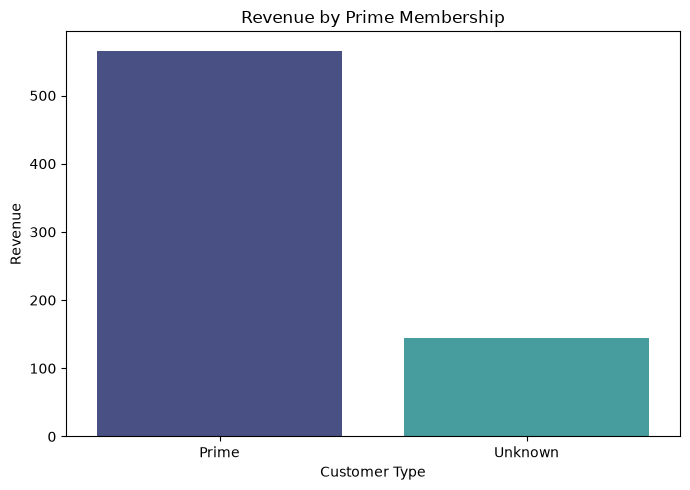

In [53]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=prime_revenue,
    x="prime_status",
    y="revenue",
    hue="prime_status",
    palette="mako",
    legend=False
)

plt.title("Revenue by Prime Membership")
plt.xlabel("Customer Type")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

## Insight: Yes, Prime customers do indeed generate more revenue than other customer groups, suggesting stronger purchasing activity from Prime members.

## Which carrier handled the most orders?

In [58]:
carrier_orders = (
    delivery_data
    .groupby("carrier", as_index=False)["order_id"]
    .nunique()
    .rename(columns={"order_id": "orders"})
    .sort_values("orders", ascending=False)
)

carrier_orders

,carrier,orders
1,UPS,3
0,FedEx,2
2,USPS,1


## Visualization 5: Orders Handled by Carrier

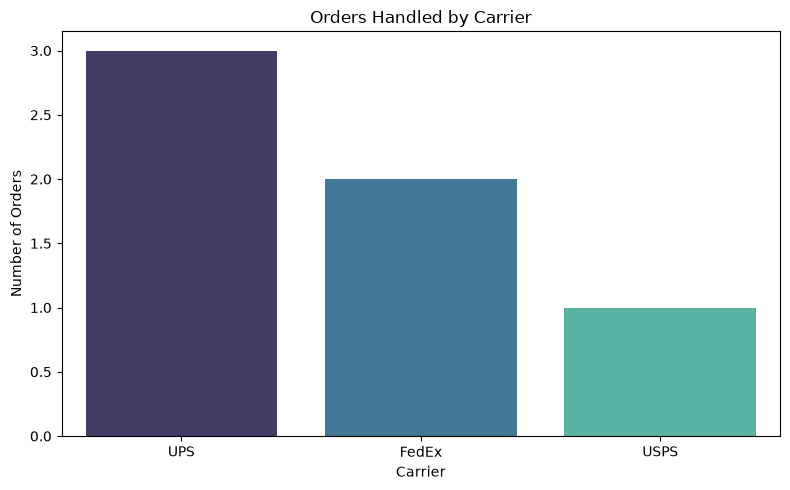

In [63]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=carrier_orders,
    x="carrier",
    y="orders",
    hue="carrier",
    palette="mako",
    legend=False
)

plt.title("Orders Handled by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

## Insight: Carrier order volume shows which shipping partners handled the most fulfilled orders in the dataset.

## Do higher-rated products make more revenue?

In [60]:
reviews = sheets["Reviews"].rename(columns={"eview_id": "review_id"})

rating_data = (
    order_product_data
    .merge(reviews, on="product_id", how="inner")
)

product_rating_revenue = (
    rating_data
    .groupby("product_name", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        avg_rating=("rating", "mean"),
        review_count=("review_id", "count")
    )
)

product_rating_revenue 

,product_name,revenue,avg_rating,review_count
0,Bluetooth Speaker,179.97,5.0,2
1,Coffee Maker,319.96,4.5,4
2,Desk Lamp,34.99,4.0,1
3,Laptop Stand,91.98,4.0,2
4,USB-C Cable,38.97,5.0,1
5,Wireless Mouse,179.94,5.0,4
6,Yoga Mat,74.97,3.0,2


## Visualization 6: Product Rating vs Revenue

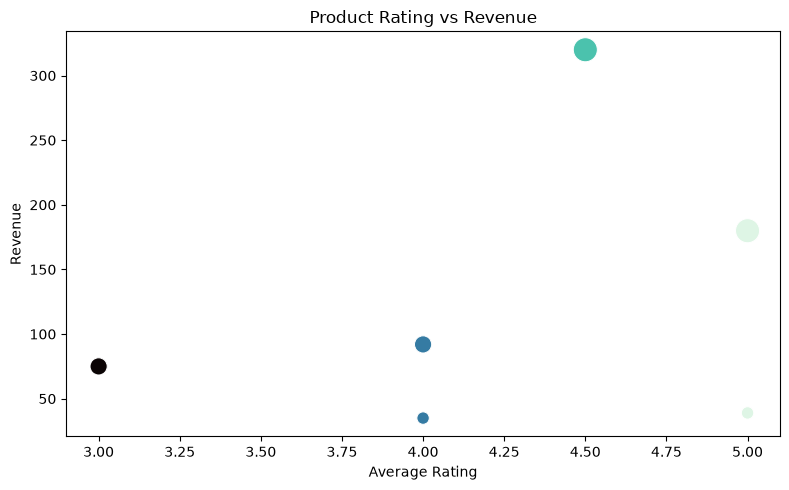

In [62]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=product_rating_revenue,
    x="avg_rating",
    y="revenue",
    size="review_count",
    hue="avg_rating",
    palette="mako",
    sizes=(80, 300),
    legend=False
)

plt.title("Product Rating vs Revenue")
plt.xlabel("Average Rating")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

## Insight: This chart compares product ratings with revenue to check whether higher-rated products also generated stronger sales.